In [2]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv", engine="python")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

Download NLTK Resources

In [4]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Check Dataset Shape

In [5]:
df.shape

(50000, 2)

Check Column Names

In [6]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [9]:
#check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
#check class distribution
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


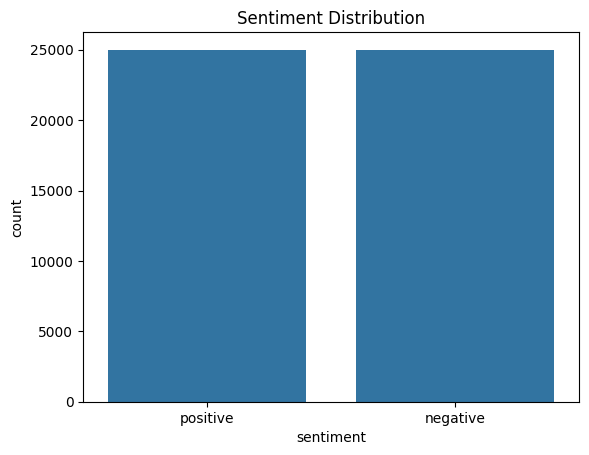

In [11]:
#visualize sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [13]:
#show sample review
df['review'].head()

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


In [14]:
#setup stopwords and stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [15]:
#create preprocessing function
def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return " ".join(tokens)

In [17]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
#apply preprocessing
df['clean_text'] = df['review'].apply(preprocess_text)

In [19]:
df[['review','clean_text']].head()

,review,clean_text
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


In [23]:
X = df['clean_text']
y = df['sentiment']

In [24]:
#bag of words
bow = CountVectorizer()
X_bow = bow.fit_transform(X)

In [25]:
X_bow.shape

(50000, 68908)

In [26]:
#TF-IDI
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

In [27]:
X_tfidf.shape

(50000, 68908)

In [28]:
#test-train split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape

(40000, 68908)

In [29]:
#logistic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [30]:
#evaluate
print("Logistic Regression Results")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8922
Precision: 0.8925656322809277
Recall: 0.8922
F1 Score: 0.8921597811357013

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [31]:
#naivebayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [32]:
#eval

In [33]:
print("Naive Bayes Results")

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results
Accuracy: 0.8615
Precision: 0.8617685876223895
Recall: 0.8615
F1 Score: 0.8614908878479928

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.87      0.86      4961
    positive       0.87      0.85      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [34]:
#decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [35]:
#eval
print("Decision Tree Results")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.725
Precision: 0.725049410444694
Recall: 0.725
F1 Score: 0.7250035640205288

Classification Report:

              precision    recall  f1-score   support

    negative       0.72      0.73      0.72      4961
    positive       0.73      0.72      0.73      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.72      0.73     10000



Observation

Logistic Regression achieved the highest accuracy among the tested models.
Naive Bayes also performed well due to its suitability for text classification tasks.
Decision Tree performed comparatively lower because it does not generalize well for
high-dimensional sparse data such as TF-IDF features.

TF-IDF feature representation helped improve performance by reducing the influence
of commonly occurring words.

Conclusion

In this project, an end-to-end Sentiment Analysis system was developed using
NLP preprocessing techniques and machine learning models.

The workflow included text preprocessing, feature extraction using TF-IDF,
training multiple ML models, and evaluating their performance.

Among the models tested, Logistic Regression achieved the best performance
with an accuracy of approximately 89%.